
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE
from torch_geometric.loader import DataLoader



from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *

c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 200

data_set = "real"         # "real" | "artificial"
type_graph_conv = "GAT"     #  GCNConv, SAGEConv, GATConv, GraphConv     #'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

if type_graph_conv == 'SAGE':
    graph_conv = SAGEConv
elif type_graph_conv == "GCN":
    graph_conv = GCNConv
elif type_graph_conv == "GAT":
    graph_conv = GATConv
elif type_graph_conv == "GraphConv":
    graph_conv = GraphConv
elif type_graph_conv == "DualGNN":
    graph_conv = DualGNN
    
    
model_used = "M7_late_fusion_inductive_learning"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

In [12]:
static_dt.min().min()

np.float64(0.0)

# Convert to tensors

In [13]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [14]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [15]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [16]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [17]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

In [18]:
print(len(train_nodes), len(test_nodes))

11712 2928


## Compute normalization ONLY from TRAIN

Dynamic normalization

In [19]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [87]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [54]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [55]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [57]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [58]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Late Fusion Architecture

In [59]:
conv_layer = GATConv  # SAGEConv, GraphConv, GCNConv 

# Static & Dynamic Encoder with Fusion

In [60]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

## Static Encoder

class StaticGCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = conv_layer(in_dim, hidden_dim)
        self.conv2 = conv_layer(hidden_dim, hidden_dim)
        # self.act = nn.LeakyReLU(0.1)
        self.act = nn.ReLU()

    def forward(self, x_static, edge_index):
        x = self.conv1(x_static, edge_index)
        x = self.act(x)
        # x = self.conv2(x, edge_index)
        return x  # [N, h]

## Dynamic Encoder
class DynamicGCNWindowEncoder(nn.Module):
    def __init__(self, window_size, hidden_dim):
        super().__init__()
        self.conv1 = conv_layer(window_size, hidden_dim)
        # self.conv2 = conv_layer(hidden_dim, hidden_dim)
        # self.act = nn.LeakyReLU(0.1)
        self.act = nn.ReLU()


    def forward(self, x_dynamic, edge_index):
        x = self.conv1(x_dynamic, edge_index)
        x = self.act (x)
        # x = self.conv2(x, edge_index)
        return x  # [N, h]

## Fuse Encoder outputs
class StaticDynamicGNN_Late_fusion(MessagePassing):
    def __init__(self, in_static, window_size, hidden_dim, out_dim, dropout=0.2):
        super().__init__()

        self.static_encoder = StaticGCNEncoder(
            in_dim=in_static,
            hidden_dim=hidden_dim
        )
        


        self.dynamic_encoder = DynamicGCNWindowEncoder(
            window_size=window_size,
            hidden_dim=hidden_dim
        )

        # self.act = nn.LeakyReLU(0.1)
        self.act = nn.ReLU()

        self.fusion_fc = nn.Linear(2 * hidden_dim, out_dim)


    def forward(self, x_static, x_dynamic, edge_index,  return_embedding = False, return_contribution = False):
        z_static = self.static_encoder(x_static, edge_index)    # [N, h]
        # z_static = self.act(z_static)
        z_dynamic = self.dynamic_encoder(x_dynamic, edge_index) # [N, h]
        
        z_fused = torch.cat([z_static, z_dynamic], dim=-1)      # [N, 2h]
        # z_fused = self.act(z_fused)
        out = self.fusion_fc(z_fused)                           # [N, 1]

        # if return_contribution:
        #     contrib = modality_contribution(z_static, z_dynamic)
        #     return out.squeeze(-1), contrib

        # if return_embedding:
        #     return z_fused
        return out.squeeze(-1), z_fused


# Late Fusioin Model

In [61]:
class CrimeForecastModel_late_fusion(nn.Module):
    def __init__(self, in_static, window_size, hidden_dim):
        super().__init__()
        self.late_fusion = StaticDynamicGNN_Late_fusion(
            in_static=in_static,
            window_size=window_size,
            hidden_dim=hidden_dim,
            out_dim=1
        )

    def forward(self, x_static, x_dynamic, edge_index, return_embedding = False, return_contribution = False):
        return self.late_fusion(x_static, x_dynamic, edge_index, return_embedding, return_contribution )


# Model initialization and optimizer

In [62]:
S = static_tensor.size(1)
model = CrimeForecastModel_late_fusion(
    in_static=S,
    window_size=W,
    hidden_dim=64
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [63]:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [64]:
patience = 5
min_delta = 1e-6
best_loss = float("inf")
epochs_no_improve = 0

criterion = nn.MSELoss()

norm_hist = []
cond_norm_hist = []
grad_hist = []

train_loss_per_epoch = []
test_loss_per_epoch = []

for epoch in range(num_epochs):
    train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
    # test_loss = evaluate_in(model, test_loader, criterion, "cpu")
    test_loss, _, _ = evaluate_and_collect(model, test_loader, "cpu")

    train_loss_per_epoch.append(train_loss)
    
    current_loss = test_loss["MSE"]
    test_loss_per_epoch.append(test_loss)

    # ---- Contribution diagnostics (1 batch is enough)
    model.eval()
    with torch.no_grad():
        batch = next(iter(train_loader))
        batch = batch.to("cpu")

        z_static = model.late_fusion.static_encoder(batch.x_static, batch.edge_index)
        z_dynamic = model.late_fusion.dynamic_encoder(batch.x_dynamic, batch.edge_index)

        # A0: naive norm
        norm_hist.append(
            modality_contribution(z_static, z_dynamic)
        )

        # A1: conditional norm
        cond_norm_hist.append(
            conditional_modality_contribution(
                z_static, z_dynamic, batch.x_dynamic
            )
        )

    # B: gradient-based
    grad_hist.append(
        gradient_modality_contribution(
            model, batch, criterion
        )
    )

    # 🔷 Early stopping logic
    if current_loss < best_loss - min_delta:
        best_loss = current_loss
        epochs_no_improve = 0
        best_state = model.state_dict()  # save best model
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.4f} | "
        f"Test {test_loss['MSE']:.4f}"
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

# 🔷 Load best model after training
model.load_state_dict(best_state)


Epoch 00 | Train 0.0026 | Test 0.0021
Epoch 01 | Train 0.0019 | Test 0.0015
Epoch 02 | Train 0.0016 | Test 0.0012
Epoch 03 | Train 0.0015 | Test 0.0011
Epoch 04 | Train 0.0014 | Test 0.0011
Epoch 05 | Train 0.0014 | Test 0.0011
Epoch 06 | Train 0.0014 | Test 0.0011
Epoch 07 | Train 0.0014 | Test 0.0011
Epoch 08 | Train 0.0014 | Test 0.0011
Epoch 09 | Train 0.0014 | Test 0.0010
Epoch 10 | Train 0.0014 | Test 0.0010
Epoch 11 | Train 0.0014 | Test 0.0010
Epoch 12 | Train 0.0014 | Test 0.0010
Epoch 13 | Train 0.0014 | Test 0.0010
Epoch 14 | Train 0.0014 | Test 0.0010
Epoch 15 | Train 0.0014 | Test 0.0010
Epoch 16 | Train 0.0014 | Test 0.0010
Epoch 17 | Train 0.0014 | Test 0.0010
Epoch 18 | Train 0.0014 | Test 0.0010
Epoch 19 | Train 0.0014 | Test 0.0010
Epoch 20 | Train 0.0014 | Test 0.0010
Epoch 21 | Train 0.0014 | Test 0.0010
Epoch 22 | Train 0.0014 | Test 0.0010
Epoch 23 | Train 0.0014 | Test 0.0010
Epoch 24 | Train 0.0014 | Test 0.0010
Epoch 25 | Train 0.0014 | Test 0.0010
Epoch 26 | T

<All keys matched successfully>

In [65]:
metrics, preds_per_t, targets_per_t = evaluate_and_collect(
    model, test_loader, device = 'cpu'
)

print(metrics)
metrics



{'MSE': 0.0010110309813171625, 'RMSE': np.float64(0.03179671337288121), 'MAE': 0.01756391115486622, 'R2': 0.6515196561813354, 'huber': 0.0005055154906585813}


{'MSE': 0.0010110309813171625,
 'RMSE': np.float64(0.03179671337288121),
 'MAE': 0.01756391115486622,
 'R2': 0.6515196561813354,
 'huber': 0.0005055154906585813}

In [66]:
import pandas as pd

df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
df.to_csv(f"{output_folder}/metrics_results_{model_used}.csv", index=False, float_format="%.6f")

# Predicted Time Series Analysis

In [67]:
def plot_fluctuation_analysis(
    pred_matrix,
    targ_matrix,
    node,
    adj,
    max_hop=2,
    mode="mean",
    output_path=None,
    filename=None,
    show_correlation=True
):
    """
    pred_matrix : shape (T, N)
    targ_matrix : shape (T, N)
    node        : central node id
    adj         : adjacency dictionary
    max_hop     : number of hops
    mode        : "mean" or "all"
    show_correlation : display correlation values in plot
    """

    T = pred_matrix.shape[0]
    time = np.arange(T)

    plt.figure(figsize=(8, 5))

    # ---- Central target node ----
    central_tar = targ_matrix[:, node]
    plt.plot(
        time,
        central_tar,
        linewidth=3,
        color="green",
        label=f"Node {node} (original)"
    )

    # ---- Central predicted node ----
    central = pred_matrix[:, node]
    plt.plot(
        time,
        central,
        linewidth=3,
        color="red",
        label=f"Node {node} (predicted)"
    )
    

    hop_colors = plt.cm.viridis(np.linspace(0.3, 0.9, max_hop))

    correlations = []

    for hop in range(1, max_hop + 1):

        neighbors = get_neighbors(node, adj, order=hop)

        if len(neighbors) == 0:
            continue

        color = hop_colors[hop - 1]

        # Mean series for hop
        hop_series = pred_matrix[:, neighbors].mean(axis=1)

        # ---- Correlation ----
        corr = np.corrcoef(central, hop_series)[0, 1]
        correlations.append((hop, corr))

        if mode == "mean":

            plt.plot(
                time,
                hop_series,
                linewidth=2,
                linestyle="--",
                color=color,
                label=f"Mean {hop}-hop (ρ={corr:.2f})"
            )

        elif mode == "all":

            for n in neighbors:
                plt.plot(
                    time,
                    pred_matrix[:, n],
                    linewidth=1.5,
                    alpha=0.4,
                    color=color
                )

            # One legend entry
            plt.plot(
                [],
                [],
                color=color,
                linewidth=2,
                label=f"{hop}-hop (ρ={corr:.2f})"
            )

    plt.xlabel("Time Step")
    plt.ylabel("Crime Intensity")
    plt.title("Spatio-Temporal Crime Evolution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # # Optional: correlation text box
    # if show_correlation and correlations:
    #     corr_text = "\n".join(
    #         [f"{hop}-hop ρ = {corr:.3f}" for hop, corr in correlations]
    #     )
    #     plt.gcf().text(
    #         0.85, 0.75,
    #         corr_text,
    #         fontsize=10,
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    #     )

    if output_path:
        file_path = os.path.join(output_path, f"{filename}.png")
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    else:
        plt.show()
        plt.close()




# Selected Nodes

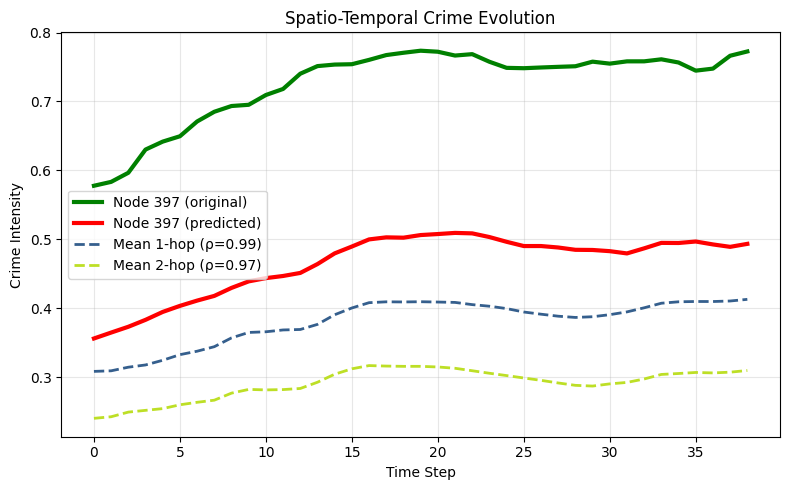

In [89]:
# adj = build_adj(edge_index)
adj = build_adj(test_dataset[0].edge_index)
pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
high_node = np.argmax(avg_pred_per_node)
high_node = 397
neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


# Choose High crime node

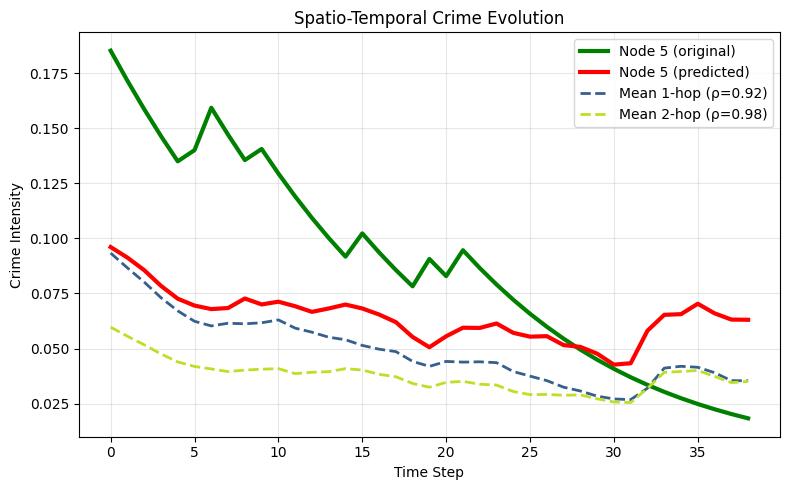

In [69]:
adj = build_adj(test_dataset[0].edge_index)
pred_matrix = np.stack(preds_per_t)
target_mat = np.stack(targets_per_t)

# Choose high-crime node
avg_pred_per_node = pred_matrix.mean(axis=0)
# high_node = np.argmax(avg_pred_per_node)
high_node =  5 #397

neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(high_node, adj, 2)

plot_fluctuation_analysis(pred_matrix, target_mat, high_node, adj, max_hop=2, mode = 'mean', output_path=output_folder, filename=f'{model_used}_high_crime_node_{high_node}')


In [70]:
neighbors_1 = get_neighbors(high_node, adj, 1)
neighbors_2 = get_neighbors(5, adj, 5)
print(neighbors_1)
print(neighbors_2)
print(high_node)


[np.int64(13521), np.int64(9092), np.int64(815)]
[np.int64(1027), np.int64(9092), np.int64(1028), np.int64(6), np.int64(1029), np.int64(7), np.int64(131), np.int64(13518), np.int64(13519), np.int64(13520), np.int64(13521), np.int64(13522), np.int64(13523), np.int64(12880), np.int64(12879), np.int64(8854), np.int64(7249), np.int64(13156), np.int64(13094), np.int64(13992), np.int64(13096), np.int64(8557), np.int64(1198), np.int64(815), np.int64(816), np.int64(1199), np.int64(9970), np.int64(1200), np.int64(9972), np.int64(1014), np.int64(13560), np.int64(13242)]
5


# Ablation Evaluation

In [71]:
static_only_loss = ablation_evaluate(model, test_loader, criterion, mode="static")
dynamic_only_loss = ablation_evaluate(model, test_loader, criterion, mode="dynamic")
print(f"Full model      : {metrics['MSE']:.4f}")
print(f"Static only     : {static_only_loss:.4f}")
print(f"Dynamic only    : {dynamic_only_loss:.4f}")

Full model      : 0.0010
Static only     : 0.0038
Dynamic only    : 0.0010


In [72]:
import pandas as pd

# Create results table
results = pd.DataFrame({
    "Model": ["Full model", "Static only", "Dynamic only"],
    "MSE": [
        metrics["MSE"],
        static_only_loss,
        dynamic_only_loss
    ]
})

# Save to CSV
results.to_csv(f"{output_folder}/ablation_results_{model_used}.csv", index=False)

print("Saved to ablation_results.csv")

Saved to ablation_results.csv


In [73]:
# def unpack_contribution(hist):
#     static = [h["static"] for h in hist]
#     dynamic = [h["dynamic"] for h in hist]
#     return static, dynamic


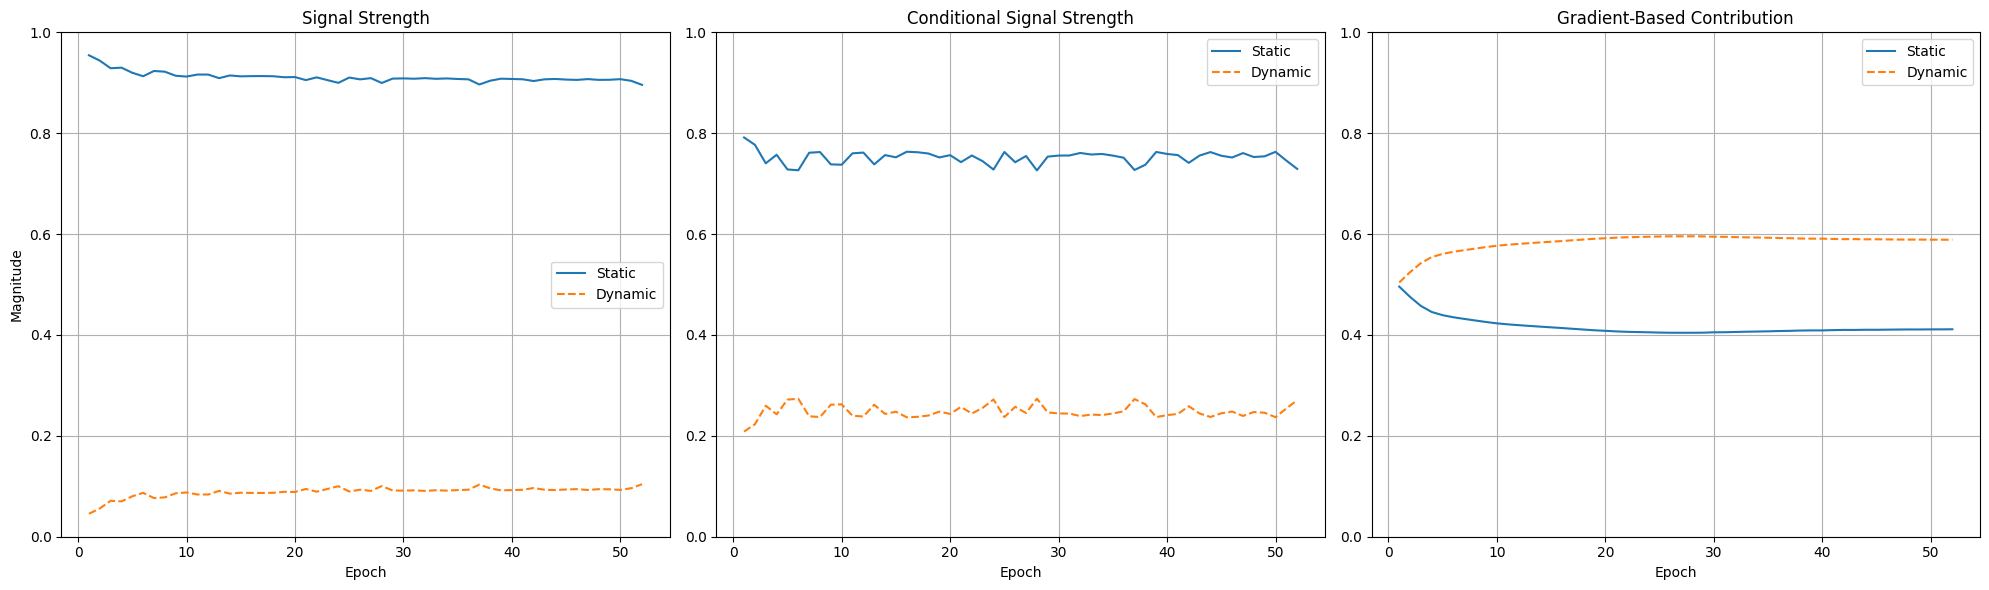

In [74]:
import matplotlib.pyplot as plt

epochs = range(1, len(norm_hist) + 1)

# unpack
norm_s, norm_d = unpack_contribution(norm_hist)
cond_s, cond_d = unpack_contribution(cond_norm_hist)
grad_s, grad_d = unpack_contribution(grad_hist)

plt.figure(figsize=(20, 6))

# ---- A0: naive norm
plt.subplot(1, 3, 1)
plt.plot(epochs, norm_s, label="Static")
plt.plot(epochs, norm_d, label="Dynamic", linestyle="--")
plt.title("Signal Strength")
plt.xlabel("Epoch")
plt.ylabel("Magnitude")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# ---- A1: conditional norm
plt.subplot(1, 3, 2)
plt.plot(epochs, cond_s, label="Static")
plt.plot(epochs, cond_d, label="Dynamic", linestyle="--")
plt.title("Conditional Signal Strength")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# ---- B: gradient-based
plt.subplot(1, 3, 3)
plt.plot(epochs, grad_s, label="Static")
plt.plot(epochs, grad_d, label="Dynamic", linestyle="--")
plt.title("Gradient-Based Contribution")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.show()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Modality_Contribution.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


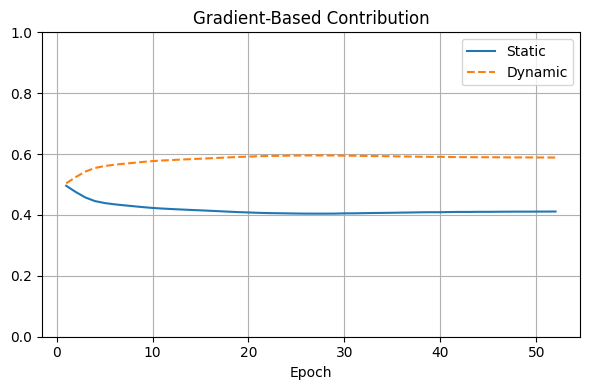

In [75]:
import matplotlib.pyplot as plt

epochs = range(1, len(norm_hist) + 1)

# unpack
norm_s, norm_d = unpack_contribution(norm_hist)
cond_s, cond_d = unpack_contribution(cond_norm_hist)
grad_s, grad_d = unpack_contribution(grad_hist)

plt.figure(figsize=(6, 4))

# ---- A0: naive norm
# plt.subplot(1, 3, 1)
# plt.plot(epochs, norm_s, label="Static")
# plt.plot(epochs, norm_d, label="Dynamic", linestyle="--")
# plt.title("Signal Strength")
# plt.xlabel("Epoch")
# plt.ylabel("Magnitude")
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(True)

# # ---- A1: conditional norm
# plt.subplot(1, 3, 2)
# plt.plot(epochs, cond_s, label="Static")
# plt.plot(epochs, cond_d, label="Dynamic", linestyle="--")
# plt.title("Conditional Signal Strength")
# plt.xlabel("Epoch")
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(True)

# # ---- B: gradient-based
# plt.subplot(1, 3, 3)
plt.plot(epochs, grad_s, label="Static")
plt.plot(epochs, grad_d, label="Dynamic", linestyle="--")
plt.title("Gradient-Based Contribution")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.show()
output_path = output_folder 
if output_path:
    file_path = os.path.join(output_path, f"Modality_gradient_Contribution_{model_used}.{save_format}")
    plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    plt.show()
    plt.close()


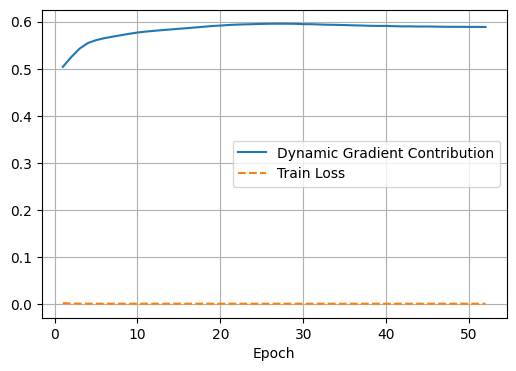

In [76]:
plt.figure(figsize=(6,4))
plt.plot(epochs, grad_d, label="Dynamic Gradient Contribution")
plt.plot(epochs, train_loss_per_epoch, label="Train Loss", linestyle="--")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [77]:
# alpha_self_history = []
# alpha_neigh_history = []
# train_loss_per_epoch = []
# test_loss_per_epoch = []
# static_hist, dynamic_hist = [], []

# for epoch in range(30):
#     train_loss = train_epoch_in(model, train_loader, optimizer, criterion, "cpu")
#     # # alpha_self = model.gnn.alpha_self.item()
#     # alpha_neigh = model.gnn.alpha_neigh.item()

#     # alpha_self_history.append(alpha_self)
#     # alpha_neigh_history.append(alpha_neigh)

#     ##______________ Contribution___________________________________
#     with torch.no_grad():
#         for batch in train_loader:
#             _, contrib = model(
#                 batch.x_static,
#                 batch.x_dynamic,
#                 batch.edge_index,
#                 return_contribution=True
#             )
#             break  # one batch is enough
    
#     static_hist.append(contrib["static"])
#     dynamic_hist.append(contrib["dynamic"])
    
#     ##______________ Contribution___________________________________

#     train_loss_per_epoch.append(train_loss)

#     test_loss = evaluate_in(model, test_loader, "cpu")
#     test_loss_per_epoch.append(test_loss)

#     print(
#         f"Epoch {epoch:02d} | "
#         f"Train: {train_loss:.4f} | "
#         # f"Self → Static: {alpha_self:.3f}, Dynamic: {1-alpha_self:.3f} | "
#         # f"Neigh → Static: {alpha_neigh:.3f}, Dynamic: {1-alpha_neigh:.3f} | "
#         f"Test: {test_loss:.4f}"
#     )

In [78]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,5))
# plt.plot(static_hist, label="Static contribution", linewidth=2)
# plt.plot(dynamic_hist, label="Dynamic contribution", linewidth=2)
# plt.xlabel("Epoch")
# plt.ylabel("Relative contribution")
# plt.title("Static vs Dynamic Contribution (Late Fusion)")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [79]:
test_loss_per_epoch

[{'MSE': 0.0020569711923599243,
  'RMSE': np.float64(0.04535384429527363),
  'MAE': 0.025190452113747597,
  'R2': 0.29100680351257324,
  'huber': 0.0010284854797646403},
 {'MSE': 0.0014573184307664633,
  'RMSE': np.float64(0.03817484028475382),
  'MAE': 0.021086011081933975,
  'R2': 0.4976940155029297,
  'huber': 0.0007286592153832316},
 {'MSE': 0.001221751212142408,
  'RMSE': np.float64(0.03495355793252538),
  'MAE': 0.01958041451871395,
  'R2': 0.5788889527320862,
  'huber': 0.000610875606071204},
 {'MSE': 0.001143515226431191,
  'RMSE': np.float64(0.03381590197571537),
  'MAE': 0.01864996738731861,
  'R2': 0.6058552265167236,
  'huber': 0.0005717576132155955},
 {'MSE': 0.00111304665915668,
  'RMSE': np.float64(0.03336235392109915),
  'MAE': 0.01842867024242878,
  'R2': 0.6163570284843445,
  'huber': 0.00055652332957834},
 {'MSE': 0.0010943581582978368,
  'RMSE': np.float64(0.033081084599780534),
  'MAE': 0.018193885684013367,
  'R2': 0.6227985620498657,
  'huber': 0.0005471791373565

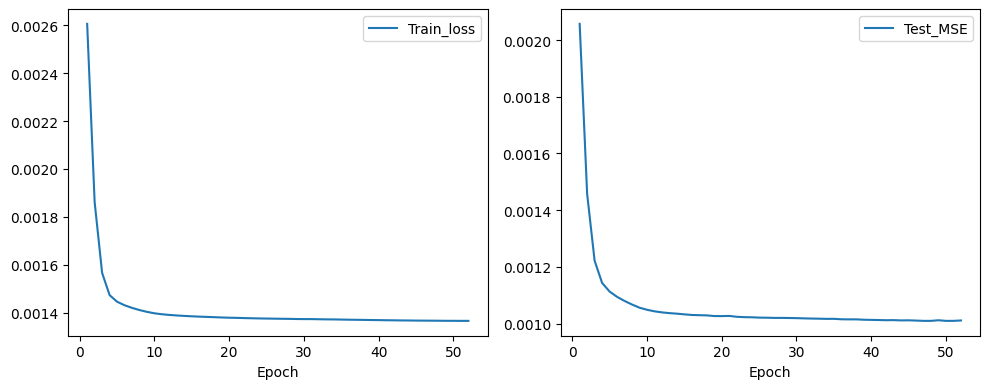

In [80]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_per_epoch, label="Train_loss")
# plt.plot(epochs, [1 - a for a in alpha_self_history], label="Dynamic", linestyle="--")
# plt.ylim(0, 1)  # Y-axis from 0 to 1
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Self Contribution")
plt.xlabel("Epoch")
# plt.ylabel("Weight")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
mse_values = [d['MSE'] for d in test_loss_per_epoch]
plt.plot(epochs, mse_values, label="Test_MSE")
# plt.plot(epochs, [1 - a for a in alpha_neigh_history], label="Dynamic", linestyle="--")

# plt.ylim(0, 1)  # Y-axis from 0 to 1
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # Integer x-axis
# plt.title("Neighbor Contribution")
plt.xlabel("Epoch")
plt.legend()
# plt.grid(True)

plt.tight_layout()
# plt.show()

# if output_path:
file_path = os.path.join(output_folder, f"train_test_loss_{model_used}.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()



In [81]:
# x_dynamic_window = test_dataset.x_dynamic[:, -3:]  # last 3 months

# model.eval()
# _,embeddings = model(
#     test_dataset.x_static,
#     x_dynamic_window,
#     test_dataset.edge_index,
#     return_embedding=True
# )
# print(f"Node Embeddings shape: {embeddings.shape}")

In [82]:
# tsne = TSNE(n_components=2, random_state=seed)
# emb_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

# tsne_result = pd.DataFrame(emb_2d)
# tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

In [83]:
# def plot_embedding(emb_2d, filename= 'embedding', output_path = None):
#     df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])

#     plt.figure(figsize=figsize)
#     sns.scatterplot(data=df_emb, x='x', y='y', palette='Set1')
#     # Save or show
#     if output_path:
#         file_path = os.path.join(output_path, f"{filename}.{save_format}")
#         plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
#         plt.show()
#         plt.close()
#     else:
#         plt.show()
#         plt.close()

In [84]:
# def plot_embedding_label(emb_2d, crime_label_tensor, filename= 'embedding', output_path = None):
#     df_emb = pd.DataFrame(emb_2d, columns=['x', 'y'])
#     df_emb['label'] = crime_label_tensor

#     plt.figure(figsize=figsize)
#     sns.scatterplot(data=df_emb, x='x', y='y', hue='label', palette='Set1')
#     # Save or show
#     if output_path:
#         file_path = os.path.join(output_path, f"{filename}.{save_format}")
#         plt.savefig(file_path, dpi=dpi, bbox_inches="tight")
#         plt.show()
#         plt.close()
#     else:
#         plt.show()
#         plt.close()

In [85]:
# plot_embedding(emb_2d, filename= f'embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

In [86]:
# plot_embedding_label(emb_2d, crime_label_col, filename= f'embedding_class_label_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)
